# CO5420 Air Pollution Forecasting

## Final Kaggle Training and Submission Notebook

### Submission summary

This standalone notebook trains the selected prediction system and creates
the final Kaggle CSV from start to finish:

1. load `train_raw.csv`, `test.csv`, and `sample_submission.csv`;
2. construct timestamps and chronological splits;
3. apply leakage-safe imputation, feature engineering, and scaling;
4. build 24-hour windows for next-hour PM2.5 forecasting;
5. train a feedforward neural network and an LSTM;
6. combine predictions using the frozen validation-selected weights;
7. validate and save `submission.csv`.

The selected blend is:

$$
\hat y = 0.49\hat y_{\mathrm{feedforward}}
       + 0.51\hat y_{\mathrm{LSTM}}.
$$

Only the approved competition files are read. `test_raw.csv` is never
accessed.

## 1. Environment and reproducibility

The default settings perform the complete training run. Set `FAST_RUN=True`
only for a quick pipeline smoke test; a smoke-test CSV is not a final
submission.

The notebook searches Kaggle input mounts automatically and also runs from
the project repository without path edits.

In [1]:
from __future__ import annotations

import gc
import hashlib
import math
import os
import random
from dataclasses import dataclass, field
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


SEED = 42
WINDOW_SIZE = 24
FEEDFORWARD_BATCH_SIZE = 512
LSTM_BATCH_SIZE = 256
FEEDFORWARD_MAX_EPOCHS = 80
LSTM_MAX_EPOCHS = 50
FEEDFORWARD_WEIGHT = 0.49
LSTM_WEIGHT = 0.51
FAST_RUN = False

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass

print("TensorFlow:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())
print("FAST_RUN:", FAST_RUN)

I0000 00:00:1785412686.144039    7128 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1785412689.238653    7128 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
FAST_RUN: False


## 2. Load and verify the competition data

The raw training frame must contain 315,648 hourly station observations.
The official test frame contains 4,103 flattened 24-hour windows.

In [2]:
def project_root() -> Path:
    current = Path.cwd()
    if current.name == "notebooks":
        current = current.parent
    return current


def locate_input_file(filename: str) -> Path:
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        matches = [
            path
            for path in kaggle_input.rglob(filename)
            if path.name == filename and path.name != "test_raw.csv"
        ]
        if not matches:
            raise FileNotFoundError(
                f"{filename} was not found under /kaggle/input. "
                "Attach the competition dataset to this notebook."
            )
        preferred = [
            path
            for path in matches
            if "co-5420-air-pollution" in str(path).lower()
        ]
        return sorted(preferred or matches, key=lambda path: len(path.parts))[0]

    local_path = project_root() / "data" / "raw" / filename
    if not local_path.exists():
        raise FileNotFoundError(f"Missing local input: {local_path}")
    return local_path


TRAIN_PATH = locate_input_file("train_raw.csv")
TEST_PATH = locate_input_file("test.csv")
SAMPLE_SUBMISSION_PATH = locate_input_file("sample_submission.csv")

raw_train = pd.read_csv(TRAIN_PATH, low_memory=False)
raw_test = pd.read_csv(TEST_PATH, low_memory=False)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

assert raw_train.shape == (315_648, 18)
assert raw_test.shape == (4_103, 386)
assert sample_submission.shape == (4_103, 2)
assert sample_submission.columns.tolist() == ["id", "PM2.5"]
assert raw_test["id"].equals(sample_submission["id"])

print("Training:", TRAIN_PATH, raw_train.shape)
print("Test:", TEST_PATH, raw_test.shape)
print("Sample submission:", SAMPLE_SUBMISSION_PATH, sample_submission.shape)
display(raw_train.head(3))

Training: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution/data/raw/train_raw.csv (315648, 18)
Test: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution/data/raw/test.csv (4103, 386)
Sample submission: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution/data/raw/sample_submission.csv (4103, 2)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin


## 3. Leakage-safe preprocessing

Rules:

- sort observations by station and timestamp;
- preserve the observed PM2.5 target separately;
- forward-fill inputs only from earlier hours in the same station;
- fill remaining leading gaps with training-period medians;
- fit numerical scaling on the training period only;
- encode calendar cycles, wind direction, station identity, and missingness.

The chronological split is determined by the prediction target timestamp:

- training: before 2015-09-01;
- validation: 2015-09-01 through 2015-11-30;
- local test: from 2015-12-01.

In [3]:
TIME_COLUMNS = ["year", "month", "day", "hour"]
NUMERIC_COLUMNS = [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM",
]
POLLUTANT_COLUMNS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
WEATHER_COLUMNS = ["TEMP", "PRES", "DEWP", "RAIN", "wd", "WSPM"]
TARGET_COLUMN = "PM2.5"
TARGET_OBSERVED_COLUMN = "target_PM2.5"
STATION_COLUMN = "station"
VALIDATION_START = pd.Timestamp("2015-09-01 00:00:00")
LOCAL_TEST_START = pd.Timestamp("2015-12-01 00:00:00")

WIND_DIRECTION_TO_DEGREES = {
    "N": 0.0, "NNE": 22.5, "NE": 45.0, "ENE": 67.5,
    "E": 90.0, "ESE": 112.5, "SE": 135.0, "SSE": 157.5,
    "S": 180.0, "SSW": 202.5, "SW": 225.0, "WSW": 247.5,
    "W": 270.0, "WNW": 292.5, "NW": 315.0, "NNW": 337.5,
}

TIME_FEATURE_COLUMNS = [
    "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos",
    "day_of_year_sin", "day_of_year_cos",
]
WIND_FEATURE_COLUMNS = ["wd_sin", "wd_cos", "wd_missing"]


def add_datetime(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["datetime"] = pd.to_datetime(result[TIME_COLUMNS], errors="raise")
    return result


def assign_split(datetimes: pd.Series) -> pd.Categorical:
    values = pd.to_datetime(datetimes, errors="raise")
    split = pd.Series("local_test", index=datetimes.index, dtype="object")
    split.loc[values < LOCAL_TEST_START] = "validation"
    split.loc[values < VALIDATION_START] = "train"
    return pd.Categorical(
        split,
        categories=["train", "validation", "local_test"],
        ordered=True,
    )

In [4]:
@dataclass
class AirPollutionPreprocessor:
    numeric_columns: tuple[str, ...] = tuple(NUMERIC_COLUMNS)
    medians_: dict[str, float] = field(default_factory=dict, init=False)
    station_categories_: list[str] = field(default_factory=list, init=False)
    scaler_: StandardScaler | None = field(default=None, init=False, repr=False)
    feature_columns_: list[str] = field(default_factory=list, init=False)
    fitted_: bool = field(default=False, init=False)

    def prepare(self, frame: pd.DataFrame) -> pd.DataFrame:
        result = frame.copy()
        if "datetime" not in result:
            result = add_datetime(result)
        else:
            result["datetime"] = pd.to_datetime(result["datetime"], errors="raise")
        result[STATION_COLUMN] = result[STATION_COLUMN].astype(str)
        if TARGET_OBSERVED_COLUMN not in result:
            result[TARGET_OBSERVED_COLUMN] = result[TARGET_COLUMN]
        return (
            result.sort_values([STATION_COLUMN, "datetime"])
            .reset_index(drop=True)
        )

    def fit(self, frame: pd.DataFrame) -> "AirPollutionPreprocessor":
        prepared = self.prepare(frame)
        medians = prepared[list(self.numeric_columns)].median()
        if medians.isna().any():
            raise ValueError("Training medians could not be calculated.")
        self.medians_ = {name: float(value) for name, value in medians.items()}
        self.station_categories_ = sorted(
            prepared[STATION_COLUMN].dropna().unique().tolist()
        )
        engineered = self.engineer(prepared, scale=False)
        self.scaler_ = StandardScaler().fit(
            engineered[list(self.numeric_columns)]
        )
        self.feature_columns_ = (
            list(self.numeric_columns)
            + TIME_FEATURE_COLUMNS
            + WIND_FEATURE_COLUMNS
            + [f"{column}_missing" for column in self.numeric_columns]
            + [f"station_{station}" for station in self.station_categories_]
        )
        self.fitted_ = True
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        if not self.fitted_:
            raise RuntimeError("Fit the preprocessor before transform.")
        result = self.engineer(self.prepare(frame), scale=True)
        output = result[
            ["datetime", STATION_COLUMN, TARGET_OBSERVED_COLUMN]
            + self.feature_columns_
        ].copy()
        if output[self.feature_columns_].isna().any().any():
            raise ValueError("Preprocessed features still contain missing values.")
        return output

    def engineer(self, frame: pd.DataFrame, *, scale: bool) -> pd.DataFrame:
        result = frame.copy()
        numeric = list(self.numeric_columns)
        for column in numeric:
            result[f"{column}_missing"] = result[column].isna().astype("float32")

        result[numeric] = (
            result.groupby(STATION_COLUMN, sort=False)[numeric].ffill()
        )
        result[numeric] = result[numeric].fillna(self.medians_)

        dt = result["datetime"]
        hour = dt.dt.hour.astype(float)
        weekday = dt.dt.dayofweek.astype(float)
        year_day = dt.dt.dayofyear.astype(float) - 1.0
        result["hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")
        result["hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")
        result["day_of_week_sin"] = np.sin(
            2 * np.pi * weekday / 7
        ).astype("float32")
        result["day_of_week_cos"] = np.cos(
            2 * np.pi * weekday / 7
        ).astype("float32")
        result["day_of_year_sin"] = np.sin(
            2 * np.pi * year_day / 365.25
        ).astype("float32")
        result["day_of_year_cos"] = np.cos(
            2 * np.pi * year_day / 365.25
        ).astype("float32")

        directions = result["wd"].astype("string").str.upper()
        degrees = directions.map(WIND_DIRECTION_TO_DEGREES)
        radians = np.deg2rad(degrees.fillna(0.0).astype(float))
        result["wd_sin"] = np.sin(radians).astype("float32")
        result["wd_cos"] = np.cos(radians).astype("float32")
        result["wd_missing"] = degrees.isna().astype("float32")

        for station in self.station_categories_:
            result[f"station_{station}"] = (
                result[STATION_COLUMN].eq(station).astype("float32")
            )

        if scale:
            if self.scaler_ is None:
                raise RuntimeError("Scaler is unavailable.")
            result[numeric] = self.scaler_.transform(
                result[numeric]
            ).astype("float32")
        else:
            result[numeric] = result[numeric].astype("float32")
        return result

In [5]:
training_source = add_datetime(raw_train)
training_source = training_source.sort_values(
    [STATION_COLUMN, "datetime"]
).reset_index(drop=True)
training_source["split"] = assign_split(training_source["datetime"])

fit_rows = training_source.loc[training_source["split"] == "train"].copy()
preprocessor = AirPollutionPreprocessor().fit(fit_rows)
processed = preprocessor.transform(training_source)
processed["split"] = assign_split(processed["datetime"])
feature_columns = preprocessor.feature_columns_

assert len(feature_columns) == 43
assert processed[feature_columns].isna().sum().sum() == 0
assert processed[TARGET_OBSERVED_COLUMN].isna().sum() == 6_372

print("Rows used to fit preprocessing:", f"{len(fit_rows):,}")
print("Processed shape:", processed.shape)
print("Model features:", len(feature_columns))

Rows used to fit preprocessing: 263,232
Processed shape: (315648, 47)
Model features: 43


## 4. Construct the 24-hour training windows

For each station and target hour $t$, the input contains rows
$t-24,\ldots,t-1$ and the label is the observed PM2.5 value at $t$.
Windows never cross station boundaries, and rows with missing true labels
are excluded.

In [6]:
def build_sequence_index(
    frame: pd.DataFrame,
    *,
    window_size: int = WINDOW_SIZE,
) -> pd.DataFrame:
    records = []
    for station, station_frame in frame.groupby(STATION_COLUMN, sort=True):
        rows = station_frame.index.to_numpy(dtype=np.int64)
        target_rows = rows[window_size:]
        starts = rows[:-window_size]
        ends = rows[window_size - 1:-1]
        targets = frame.loc[target_rows, TARGET_OBSERVED_COLUMN].to_numpy(
            dtype=np.float64
        )
        valid = np.isfinite(targets)
        target_rows, starts, ends, targets = (
            target_rows[valid],
            starts[valid],
            ends[valid],
            targets[valid],
        )
        target_times = frame.loc[target_rows, "datetime"].to_numpy(
            dtype="datetime64[ns]"
        )
        end_times = frame.loc[ends, "datetime"].to_numpy(dtype="datetime64[ns]")
        if not np.all(target_times - end_times == np.timedelta64(1, "h")):
            raise ValueError(f"Non-consecutive window detected at {station}.")
        records.append(
            pd.DataFrame(
                {
                    "station": station,
                    "window_start_row": starts,
                    "window_end_row": ends,
                    "target_row": target_rows,
                    "target_datetime": target_times,
                    "split": frame.loc[target_rows, "split"].astype(str).to_numpy(),
                    "target": targets.astype("float32"),
                }
            )
        )
    index = pd.concat(records, ignore_index=True)
    index.insert(0, "sequence_id", np.arange(len(index), dtype=np.int64))
    return index


sequence_index = build_sequence_index(processed)
split_counts = sequence_index["split"].value_counts().reindex(
    ["train", "validation", "local_test"]
)

assert len(sequence_index) == 308_988
assert split_counts.to_dict() == {
    "train": 257_639,
    "validation": 25_458,
    "local_test": 25_891,
}

display(split_counts.to_frame("sequences"))

,sequences
split,
train,257639
validation,25458
local_test,25891


In [7]:
class TemporalWindowDataset(tf.keras.utils.PyDataset):
    def __init__(
        self,
        feature_matrix: np.ndarray,
        index: pd.DataFrame,
        *,
        batch_size: int,
        shuffle: bool,
        seed: int,
    ):
        super().__init__()
        self.features = np.asarray(feature_matrix, dtype=np.float32)
        self.starts = index["window_start_row"].to_numpy(dtype=np.int64)
        self.targets = index["target"].to_numpy(dtype=np.float32)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.offsets = np.arange(WINDOW_SIZE, dtype=np.int64)
        self.order = np.arange(len(index), dtype=np.int64)
        self.rng = np.random.default_rng(seed)
        if shuffle:
            self.rng.shuffle(self.order)

    def __len__(self) -> int:
        return math.ceil(len(self.order) / self.batch_size)

    def __getitem__(self, batch_index: int):
        selected = self.order[
            batch_index * self.batch_size:
            (batch_index + 1) * self.batch_size
        ]
        rows = self.starts[selected, None] + self.offsets[None, :]
        return self.features[rows], self.targets[selected, None]

    def on_epoch_end(self) -> None:
        if self.shuffle:
            self.rng.shuffle(self.order)


train_index = sequence_index.loc[
    sequence_index["split"] == "train"
].reset_index(drop=True)
validation_index = sequence_index.loc[
    sequence_index["split"] == "validation"
].reset_index(drop=True)

if FAST_RUN:
    train_index = train_index.sample(
        n=min(8_192, len(train_index)),
        random_state=SEED,
    ).sort_values("sequence_id").reset_index(drop=True)
    FEEDFORWARD_MAX_EPOCHS = 1
    LSTM_MAX_EPOCHS = 1

feature_matrix = processed[feature_columns].to_numpy(dtype=np.float32)
train_temporal = TemporalWindowDataset(
    feature_matrix,
    train_index,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
validation_temporal = TemporalWindowDataset(
    feature_matrix,
    validation_index,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)

print("Training samples:", f"{len(train_index):,}")
print("Validation samples:", f"{len(validation_index):,}")
print("One temporal batch:", train_temporal[0][0].shape)

Training samples: 257,639
Validation samples: 25,458
One temporal batch: (256, 24, 43)


## 5. Build the feedforward feature matrix

The feedforward network uses 115 engineered predictors:

- the latest values of all 43 processed inputs;
- all 24 PM2.5 lags;
- mean, standard deviation, minimum, and maximum for 11 numerical inputs;
- PM2.5 changes over 1, 3, 6, and 12 hours.

In [8]:
def build_tabular_features(
    frame: pd.DataFrame,
    index: pd.DataFrame,
) -> tuple[np.ndarray, list[str]]:
    starts = index["window_start_row"].to_numpy(dtype=np.int64)
    ends = index["window_end_row"].to_numpy(dtype=np.int64)
    positions = starts[:, None] + np.arange(WINDOW_SIZE)[None, :]

    all_values = frame[feature_columns].to_numpy(dtype=np.float32)
    latest = all_values[ends]
    latest_names = [f"latest_{column}" for column in feature_columns]

    pm25_position = feature_columns.index("PM2.5")
    pm25_history = all_values[positions, pm25_position]
    pm25_names = [f"PM2.5_lag_{lag}" for lag in range(24, 0, -1)]

    numeric_values = frame[NUMERIC_COLUMNS].to_numpy(dtype=np.float32)
    numeric_history = numeric_values[positions]
    summaries = [
        numeric_history.mean(axis=1, dtype=np.float64).astype("float32"),
        numeric_history.std(axis=1, dtype=np.float64).astype("float32"),
        numeric_history.min(axis=1),
        numeric_history.max(axis=1),
    ]
    summary_names = [
        f"{column}_{statistic}_{WINDOW_SIZE}"
        for statistic in ["mean", "std", "min", "max"]
        for column in NUMERIC_COLUMNS
    ]

    deltas = []
    delta_names = []
    for hours in [1, 3, 6, 12]:
        deltas.append(
            (pm25_history[:, -1] - pm25_history[:, -(hours + 1)])[:, None]
        )
        delta_names.append(f"PM2.5_change_{hours}h")

    matrix = np.concatenate(
        [latest, pm25_history, *summaries, *deltas],
        axis=1,
    ).astype("float32")
    names = latest_names + pm25_names + summary_names + delta_names
    if matrix.shape[1] != len(names) or not np.isfinite(matrix).all():
        raise ValueError("Invalid tabular feature matrix.")
    return matrix, names


X_train_tabular, tabular_feature_names = build_tabular_features(
    processed, train_index
)
X_validation_tabular, validation_feature_names = build_tabular_features(
    processed, validation_index
)
y_train = train_index["target"].to_numpy(dtype=np.float32)
y_validation = validation_index["target"].to_numpy(dtype=np.float32)

assert tabular_feature_names == validation_feature_names
assert X_train_tabular.shape[1] == 115

print("Feedforward training matrix:", X_train_tabular.shape)
print("Feedforward validation matrix:", X_validation_tabular.shape)

Feedforward training matrix: (257639, 115)
Feedforward validation matrix: (25458, 115)


## 6. Define and train the selected models

The feedforward network learns from explicit lag and summary features. The
LSTM processes the original `24 × 43` sequence. Both predict PM2.5 directly
in its original units using mean squared error and Adam optimisation.

In [9]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def build_feedforward(input_dimension: int) -> tf.keras.Model:
    regularizer = tf.keras.regularizers.L2(1e-5)
    inputs = tf.keras.Input((input_dimension,), name="tabular_features")
    x = tf.keras.layers.Dense(
        128, activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=SEED),
        kernel_regularizer=regularizer,
    )(inputs)
    x = tf.keras.layers.Dropout(0.20, seed=SEED + 1)(x)
    x = tf.keras.layers.Dense(
        64, activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=SEED + 2),
        kernel_regularizer=regularizer,
    )(x)
    x = tf.keras.layers.Dropout(0.15, seed=SEED + 3)(x)
    x = tf.keras.layers.Dense(
        32, activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=SEED + 4),
        kernel_regularizer=regularizer,
    )(x)
    outputs = tf.keras.layers.Dense(
        1,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED + 5),
    )(x)
    model = tf.keras.Model(inputs, outputs, name="feedforward_pm25")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
        ],
    )
    return model


def build_lstm(input_shape: tuple[int, int]) -> tf.keras.Model:
    regularizer = tf.keras.regularizers.L2(1e-5)
    inputs = tf.keras.Input(input_shape, name="temporal_features")
    x = tf.keras.layers.LSTM(
        64,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=SEED + 1),
        kernel_regularizer=regularizer,
        recurrent_regularizer=regularizer,
    )(inputs)
    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.Dropout(0.20, seed=SEED + 2)(x)
    x = tf.keras.layers.Dense(
        32, activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=SEED + 3),
        kernel_regularizer=regularizer,
    )(x)
    x = tf.keras.layers.Dropout(0.10, seed=SEED + 4)(x)
    outputs = tf.keras.layers.Dense(
        1,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED + 5),
    )(x)
    model = tf.keras.Model(inputs, outputs, name="lstm_pm25")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
        ],
    )
    return model


def training_callbacks(patience: int) -> list[tf.keras.callbacks.Callback]:
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_rmse",
            mode="min",
            patience=patience,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_rmse",
            mode="min",
            patience=4 if patience >= 10 else 3,
            factor=0.5,
            min_lr=1e-6,
        ),
    ]

In [10]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

feedforward_model = build_feedforward(X_train_tabular.shape[1])
feedforward_history = feedforward_model.fit(
    X_train_tabular,
    y_train,
    validation_data=(X_validation_tabular, y_validation),
    epochs=FEEDFORWARD_MAX_EPOCHS,
    batch_size=FEEDFORWARD_BATCH_SIZE,
    shuffle=True,
    callbacks=training_callbacks(patience=10),
    verbose=2,
)

feedforward_validation_predictions = np.maximum(
    feedforward_model.predict(
        X_validation_tabular, batch_size=1024, verbose=0
    ).reshape(-1),
    0.0,
)
print(
    "Feedforward validation:",
    regression_metrics(y_validation, feedforward_validation_predictions),
)

Epoch 1/80


E0000 00:00:1785412701.197745    7128 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1785412715.863235    7128 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


504/504 - 16s - 31ms/step - loss: 1222.8040 - mae: 19.3613 - rmse: 34.9685 - val_loss: 275.7405 - val_mae: 9.5828 - val_rmse: 16.6053 - learning_rate: 0.0010


Epoch 2/80


...

504/504 - 4s - 8ms/step - loss: 335.5497 - mae: 10.7606 - rmse: 18.3178 - val_loss: 395.5036 - val_mae: 11.3928 - val_rmse: 19.8871 - learning_rate: 2.5000e-04


Epoch 14/80


504/504 - 4s - 8ms/step - loss: 335.4171 - mae: 10.7352 - rmse: 18.3142 - val_loss: 401.8873 - val_mae: 11.4793 - val_rmse: 20.0469 - learning_rate: 2.5000e-04


E0000 00:00:1785412785.104585    7128 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Feedforward validation: {'rmse': 15.673279901822061, 'mae': 8.739892959594727, 'r2': 0.9679198861122131}


In [11]:
tf.keras.utils.set_random_seed(SEED)

lstm_model = build_lstm((WINDOW_SIZE, len(feature_columns)))
lstm_history = lstm_model.fit(
    train_temporal,
    validation_data=validation_temporal,
    epochs=LSTM_MAX_EPOCHS,
    callbacks=training_callbacks(patience=8),
    verbose=2,
)

lstm_validation_predictions = np.maximum(
    lstm_model.predict(validation_temporal, verbose=0).reshape(-1),
    0.0,
)
print(
    "LSTM validation:",
    regression_metrics(y_validation, lstm_validation_predictions),
)

Epoch 1/50


1007/1007 - 15s - 14ms/step - loss: 1872.7970 - mae: 22.8056 - rmse: 43.2758 - val_loss: 367.6978 - val_mae: 9.2668 - val_rmse: 19.1753 - learning_rate: 0.0010


Epoch 2/50


1007/1007 - 10s - 10ms/step - loss: 475.4053 - mae: 13.2567 - rmse: 21.8037 - val_loss: 305.6443 - val_mae: 8.8924 - val_rmse: 17.4825 - learning_rate: 0.0010


Epoch 3/50


...

Epoch 33/50


1007/1007 - 11s - 11ms/step - loss: 342.8881 - mae: 11.2140 - rmse: 18.5169 - val_loss: 253.2761 - val_mae: 8.5392 - val_rmse: 15.9142 - learning_rate: 6.2500e-05


Epoch 34/50


1007/1007 - 11s - 10ms/step - loss: 343.6893 - mae: 11.2067 - rmse: 18.5385 - val_loss: 248.6663 - val_mae: 8.5108 - val_rmse: 15.7687 - learning_rate: 6.2500e-05


LSTM validation: {'rmse': 15.70660380076169, 'mae': 8.455662727355957, 'r2': 0.9677833318710327}


## 7. Validate the frozen 49/51 ensemble

The blend was selected in the controlled project experiment using validation
RMSE only. The local test and Kaggle leaderboard were not used to choose the
weight. This cell reports the current run's validation metrics and shows the
weight-search neighbourhood as a reproducibility check.

Best weight in this deterministic run:


,feedforward_weight,lstm_weight,rmse,mae,r2
51,0.51,0.49,15.282495,8.290780,0.969500
52,0.52,0.48,15.282648,8.293933,0.969499
50,0.50,0.50,15.282672,8.287926,0.969499
53,0.53,0.47,15.283132,8.297353,0.969497
49,0.49,0.51,15.283179,8.285252,0.969497


Frozen selected weights: 0.49 0.51
Frozen ensemble validation: {'rmse': 15.283179537721415, 'mae': 8.28525161743164, 'r2': 0.9694969058036804}


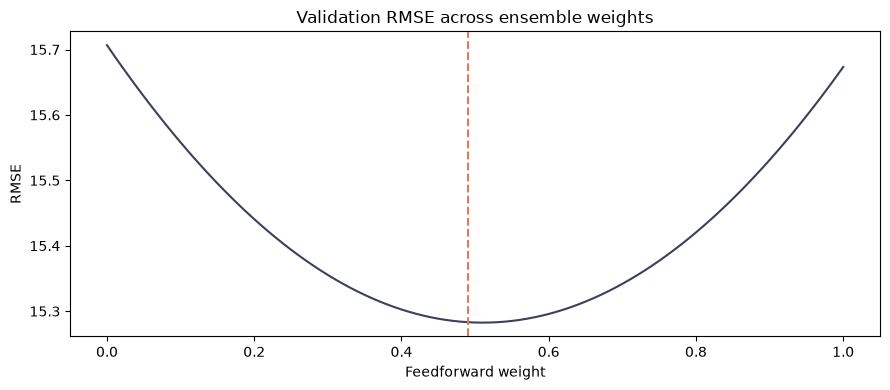

In [12]:
weight_records = []
for feedforward_weight in np.linspace(0.0, 1.0, 101):
    predictions = (
        feedforward_weight * feedforward_validation_predictions
        + (1.0 - feedforward_weight) * lstm_validation_predictions
    )
    weight_records.append(
        {
            "feedforward_weight": feedforward_weight,
            "lstm_weight": 1.0 - feedforward_weight,
            **regression_metrics(y_validation, predictions),
        }
    )

weight_search = pd.DataFrame(weight_records).sort_values(["rmse", "mae"])
selected_validation_predictions = (
    FEEDFORWARD_WEIGHT * feedforward_validation_predictions
    + LSTM_WEIGHT * lstm_validation_predictions
)
selected_validation_metrics = regression_metrics(
    y_validation, selected_validation_predictions
)

print("Best weight in this deterministic run:")
display(weight_search.head(5))
print("Frozen selected weights:", FEEDFORWARD_WEIGHT, LSTM_WEIGHT)
print("Frozen ensemble validation:", selected_validation_metrics)

axis = weight_search.sort_values("feedforward_weight").plot(
    x="feedforward_weight",
    y="rmse",
    figsize=(9, 4),
    legend=False,
    color="#3D405B",
)
axis.axvline(FEEDFORWARD_WEIGHT, color="#E07A5F", linestyle="--")
axis.set_title("Validation RMSE across ensemble weights")
axis.set_xlabel("Feedforward weight")
axis.set_ylabel("RMSE")
plt.tight_layout()
plt.show()

## 8. Reconstruct and preprocess the official test windows

Every row in `test.csv` is an independent 24-hour sequence. Forward filling
is therefore performed inside each test row only; values are never carried
from one test sample into another.

In [13]:
RAW_SEQUENCE_COLUMNS = (
    TIME_COLUMNS + POLLUTANT_COLUMNS + WEATHER_COLUMNS
)


def reshape_test_windows(test_frame: pd.DataFrame) -> pd.DataFrame:
    parts = []
    window_ids = np.arange(len(test_frame), dtype=np.int64)
    for time_step, lag in enumerate(range(WINDOW_SIZE, 0, -1)):
        lag_columns = [
            f"{column}_lag_{lag}" for column in RAW_SEQUENCE_COLUMNS
        ]
        missing = [column for column in lag_columns if column not in test_frame]
        if missing:
            raise ValueError(f"Missing test columns: {missing[:5]}")
        part = test_frame[["id", STATION_COLUMN] + lag_columns].copy()
        part = part.rename(
            columns={
                f"{column}_lag_{lag}": column
                for column in RAW_SEQUENCE_COLUMNS
            }
        )
        part["window_id"] = window_ids
        part["time_step"] = time_step
        parts.append(part)

    long_frame = (
        pd.concat(parts, ignore_index=True)
        .sort_values(["window_id", "time_step"])
        .reset_index(drop=True)
    )
    long_frame["datetime"] = pd.to_datetime(
        long_frame[TIME_COLUMNS], errors="raise"
    )
    differences = long_frame.groupby("window_id")["datetime"].diff()
    invalid = differences.notna() & differences.ne(pd.Timedelta(hours=1))
    if invalid.any():
        raise ValueError("A test window contains non-hourly timestamps.")
    return long_frame


def transform_test_windows(
    test_frame: pd.DataFrame,
) -> tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    long_frame = reshape_test_windows(test_frame)
    numeric = list(preprocessor.numeric_columns)

    for column in numeric:
        long_frame[f"{column}_missing"] = (
            long_frame[column].isna().astype("float32")
        )
    long_frame[numeric] = (
        long_frame.groupby("window_id", sort=False)[numeric].ffill()
    )
    long_frame[numeric] = long_frame[numeric].fillna(preprocessor.medians_)

    dt = long_frame["datetime"]
    hour = dt.dt.hour.astype(float)
    weekday = dt.dt.dayofweek.astype(float)
    year_day = dt.dt.dayofyear.astype(float) - 1.0
    long_frame["hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")
    long_frame["hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")
    long_frame["day_of_week_sin"] = np.sin(
        2 * np.pi * weekday / 7
    ).astype("float32")
    long_frame["day_of_week_cos"] = np.cos(
        2 * np.pi * weekday / 7
    ).astype("float32")
    long_frame["day_of_year_sin"] = np.sin(
        2 * np.pi * year_day / 365.25
    ).astype("float32")
    long_frame["day_of_year_cos"] = np.cos(
        2 * np.pi * year_day / 365.25
    ).astype("float32")

    degrees = (
        long_frame["wd"].astype("string").str.upper()
        .map(WIND_DIRECTION_TO_DEGREES)
    )
    radians = np.deg2rad(degrees.fillna(0.0).astype(float))
    long_frame["wd_sin"] = np.sin(radians).astype("float32")
    long_frame["wd_cos"] = np.cos(radians).astype("float32")
    long_frame["wd_missing"] = degrees.isna().astype("float32")

    unknown_stations = set(long_frame[STATION_COLUMN]) - set(
        preprocessor.station_categories_
    )
    if unknown_stations:
        raise ValueError(f"Unknown test stations: {sorted(unknown_stations)}")
    for station in preprocessor.station_categories_:
        long_frame[f"station_{station}"] = (
            long_frame[STATION_COLUMN].eq(station).astype("float32")
        )

    if preprocessor.scaler_ is None:
        raise RuntimeError("Training scaler is unavailable.")
    long_frame[numeric] = preprocessor.scaler_.transform(
        long_frame[numeric]
    ).astype("float32")

    flat = long_frame[feature_columns].reset_index(drop=True)
    if flat.isna().any().any():
        raise ValueError("Test features contain missing values.")
    tensor = flat.to_numpy(dtype=np.float32).reshape(
        len(test_frame), WINDOW_SIZE, len(feature_columns)
    )
    starts = np.arange(len(test_frame), dtype=np.int64) * WINDOW_SIZE
    test_index = pd.DataFrame(
        {
            "window_start_row": starts,
            "window_end_row": starts + WINDOW_SIZE - 1,
        }
    )
    return flat, tensor, test_index


test_flat_features, test_sequence_tensor, test_sequence_index = (
    transform_test_windows(raw_test)
)
X_test_tabular, test_tabular_names = build_tabular_features(
    test_flat_features, test_sequence_index
)

assert tabular_feature_names == test_tabular_names
assert test_sequence_tensor.shape == (4_103, 24, 43)
assert X_test_tabular.shape == (4_103, 115)

print("Test temporal tensor:", test_sequence_tensor.shape)
print("Test tabular matrix:", X_test_tabular.shape)

Test temporal tensor: (4103, 24, 43)
Test tabular matrix: (4103, 115)


## 9. Predict, blend, and create the submission

The final file is written to `/kaggle/working/submission.csv` on Kaggle and
to `data/submissions/final_kaggle_notebook_submission.csv` when executed
inside the project repository.

In [14]:
feedforward_test_predictions = np.maximum(
    feedforward_model.predict(
        X_test_tabular, batch_size=1024, verbose=0
    ).reshape(-1),
    0.0,
)
lstm_test_predictions = np.maximum(
    lstm_model.predict(
        test_sequence_tensor, batch_size=1024, verbose=0
    ).reshape(-1),
    0.0,
)

ensemble_test_predictions = np.maximum(
    FEEDFORWARD_WEIGHT * feedforward_test_predictions
    + LSTM_WEIGHT * lstm_test_predictions,
    0.0,
)

submission = sample_submission.copy()
submission["PM2.5"] = ensemble_test_predictions.astype(np.float64)

assert submission.shape == (4_103, 2)
assert submission.columns.tolist() == ["id", "PM2.5"]
assert submission["id"].equals(raw_test["id"])
assert submission["id"].is_unique
assert np.isfinite(submission["PM2.5"]).all()
assert submission["PM2.5"].ge(0).all()

if Path("/kaggle/working").exists():
    submission_path = Path(
        "/kaggle/working/smoke_submission.csv"
        if FAST_RUN
        else "/kaggle/working/submission.csv"
    )
else:
    submission_path = (
        project_root()
        / "data"
        / "submissions"
        / (
            "smoke_submission.csv"
            if FAST_RUN
            else "final_kaggle_notebook_submission.csv"
        )
    )
    submission_path.parent.mkdir(parents=True, exist_ok=True)

submission.to_csv(submission_path, index=False)
submission_sha256 = hashlib.sha256(submission_path.read_bytes()).hexdigest()

print("Submission saved:", submission_path)
print("SHA-256:", submission_sha256)
print("Rows:", len(submission))
print("Missing predictions:", submission["PM2.5"].isna().sum())
print("Negative predictions:", submission["PM2.5"].lt(0).sum())
display(submission.head())
display(submission["PM2.5"].describe().to_frame())

E0000 00:00:1785413142.303244    7128 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Submission saved: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution/data/submissions/final_kaggle_notebook_submission.csv
SHA-256: a8038724c365dcf73e1fd199fc238c095c0525051af6e4e39ea8b767f70f6a07
Rows: 4103
Missing predictions: 0
Negative predictions: 0


,id,PM2.5
0,test_00001,186.704727
1,test_00002,163.562820
2,test_00003,425.789429
3,test_00004,86.365417
4,test_00005,47.168709


,PM2.5
count,4103.000000
mean,77.073435
std,80.255446
min,6.694285
25%,17.974966
50%,54.229546
75%,100.998642
max,551.779358


## 10. Final checks and takeaways

- The notebook contains the complete path from raw data to submission.
- Preprocessing statistics are learned from the chronological training split.
- The input window is 24 hours and the output is next-hour PM2.5.
- The selected system combines complementary tabular and recurrent models.
- Test samples are transformed independently.
- The generated CSV preserves the official ID order and contains no invalid
  or negative predictions.
- No competition-period target file is used anywhere in this workflow.

For the module submission, download `submission.csv` from the Kaggle
Notebook output and submit it together with this notebook.